# Continuous-time linear demo
These are not actual experiments, but anyway demonstrate how the routines are used.

In [1]:
import numpy as np
from scipy import linalg
from cmap.clqt_jax import CLQT
from cmap.Linear_model_jax import getCLQT 
import jax
import matplotlib.pyplot as plt
from jax import config
import jax.numpy as jnp
from cmap.Linear_model_data import make_cv_data
config.update("jax_enable_x64", True)
# config.update("jax_platform_name", "cuda")


This is how the continuous version of the tracking data is formed

In [2]:
nsteps = 5000
x0=jnp.array([5.0,5.0,0.0,0.0])

dt=50.0/nsteps
P0=0.01*np.eye(4)
q=0.2
r=0.001
T, X, dotz, Y,dotz2=make_cv_data( x0, P0,nsteps, dt, q, r, seed=123)

In [3]:
t_grid = np.arange(nsteps) * dt
s=jnp.stack([dotz(t) for t in t_grid], axis=0)
DY_dt_recovered = np.stack([dotz(t) for t in t_grid], axis=0)
np.shape(DY_dt_recovered)
# np.savetxt('con-meas.txt',dotz)

(5000, 2)

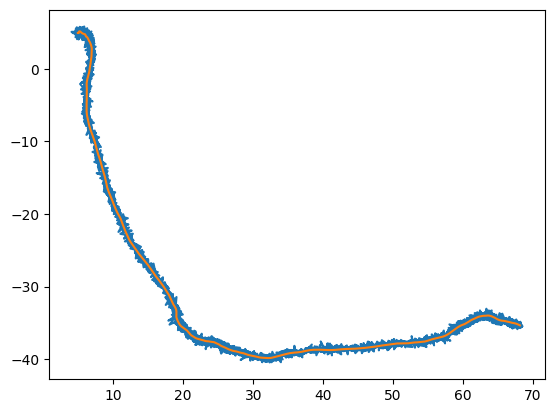

In [4]:
plt.plot(DY_dt_recovered[:,0], DY_dt_recovered[:,1], label='True velocity x')
plt.plot(X[:,0], X[:,1], label='True velocity x')


Apply control and show the result

In [5]:
from cmap.KB import kalman_bucy_filter
from cmap.KB import continuous_rts_smoother


In [6]:

# cx = jnp.array([5.7770, -2.6692, 1.1187, 0.1379, 0.5718, 1.1214,
#                 0.2998, 0.3325, 0.7451, 0.2117, 0.6595, 0.0401, -0.2995])
# cy = jnp.array([4.3266, -1.4584, -1.2457, 1.1804, 0.2035, 0.5123,
#                 1.0588, 0.2616, -0.6286, -0.3802, 0.2750, -0.0070, -0.0022])

# y = lambda t: jnp.array([cx[0] +
#              cx[1] * jnp.cos(2.0 * jnp.pi * t / 50.0) + cx[2] * jnp.sin(2.0 * jnp.pi * t / 50.0) +
#                cx[3] * jnp.cos(4.0 * jnp.pi * t / 50.0) + cx[4] * jnp.sin(4.0 * jnp.pi * t / 50.0) +
#                cx[5] * jnp.cos(6.0 * jnp.pi * t / 50.0) + cx[6] * jnp.sin(6.0 * jnp.pi * t / 50.0) +
#                cx[7] * jnp.cos(8.0 * jnp.pi * t / 50.0) + cx[8] * jnp.sin(8.0 * jnp.pi * t / 50.0) +
#                cx[9] * jnp.cos(10.0 * jnp.pi * t / 50.0) + cx[10] * jnp.sin(10.0 * jnp.pi * t / 50.0) +
#                cx[11] * jnp.cos(12.0 * jnp.pi * t / 50.0) + cx[12] * jnp.sin(12.0 * jnp.pi * t / 50.0),
#                cy[0] +
#                cy[1] * jnp.cos(2.0 * jnp.pi * t / 50.0) + cy[2] * jnp.sin(2.0 * jnp.pi * t / 50.0) +
#                cy[3] * jnp.cos(4.0 * jnp.pi * t / 50.0) + cy[4] * jnp.sin(4.0 * jnp.pi * t / 50.0) +
#               cy[5] * jnp.cos(6.0 * jnp.pi * t / 50.0) + cy[6] * jnp.sin(6.0 * jnp.pi * t / 50.0) +
#               cy[7] * jnp.cos(8.0 * jnp.pi * t / 50.0) + cy[8] * jnp.sin(8.0 * jnp.pi * t / 50.0) +
#               cy[9] * jnp.cos(10.0 * jnp.pi * t / 50.0) + cy[10] * jnp.sin(10.0 * jnp.pi * t / 50.0) +
#               cy[11] * jnp.cos(12.0 * jnp.pi * t / 50.0) + cy[12] * jnp.sin(12.0 * jnp.pi * t / 50.0)
#                      ])

F = lambda t: jnp.array([[0.,0,1,0],
               [0,0,0,1],
               [0,0,0,0],
               [0,0,0,0]])
L = lambda t: jnp.array([[0,0],[0,0],[1,0],[0,1]])
H = lambda t: jnp.array([[1,0,0,0],[0,1,0,0]])
Q = lambda t: jnp.eye(2) * 0.2
R = lambda t:jnp.eye(2) * 0.001


Sigma = 0.01 * jnp.eye(4)
x0=jnp.array([5.0,5.0,0.0,0.0])
t0= 0.0

step_seq=5000

dt=50.0/step_seq

t_eval = t0 + dt * np.arange(step_seq)
# y_discrete = np.array([y(tk) for tk in t_eval])


Ps,ms = kalman_bucy_filter(F, L, Q, H, R, dotz, step_seq, dt,t0, Sigma, x0)
ms_s, Ps_s = continuous_rts_smoother(Ps, ms, F, L, Q, t_eval, dt)


In [7]:
import jax.numpy as jnp
import cmap.Linear_model_jax as linear_model_jax
from cmap.clqt_jax import seqBackwardPass
from cmap.clqt_jax import seqForwardPass
from cmap.clqt_jax import parBackwardPass
from cmap.clqt_jax import parForwardPass


In [8]:
clqt, x0 = getCLQT(CLQT)

blocks = 500
steps = 10
t0 = 0.0
dt = clqt.T / steps / blocks
sigma=clqt.Sigma(0)
mu=clqt.mu


S_list_jax_seq, v_list_jax_seq,Kx_list_jax_seq, d_list_jax_seq = seqBackwardPass(clqt,steps*blocks,dt,t0,sigma,sigma@mu)
phi0= jnp.linalg.solve(S_list_jax_seq[0] ,v_list_jax_seq[0])
phis=jnp.linalg.solve(S_list_jax_seq ,v_list_jax_seq)
x_list_jax_seq,u_list_jax_seq =seqForwardPass(clqt, dt, clqt.T, phi0, Kx_list_jax_seq, d_list_jax_seq,u_zoh=False)


k_rev: 0
k_rev: 1
k_rev: 3
k_rev: 4
k_rev: 4
k_rev: 6
k_rev: 7
k_rev: 8
k_rev: 8
k_rev: 10
k_rev: 11
k_rev: 11
k_rev: 12
k_rev: 14
k_rev: 15
k_rev: 15
k_rev: 17
k_rev: 18
k_rev: 18
k_rev: 19
k_rev: 21
k_rev: 22
k_rev: 22
k_rev: 24
k_rev: 25
k_rev: 25
k_rev: 26
k_rev: 28
k_rev: 29
k_rev: 29
k_rev: 31
k_rev: 32
k_rev: 33
k_rev: 33
k_rev: 35
k_rev: 36
k_rev: 36
k_rev: 37
k_rev: 39
k_rev: 40
k_rev: 40
k_rev: 42
k_rev: 43
k_rev: 43
k_rev: 44
k_rev: 46
k_rev: 47
k_rev: 47
k_rev: 49
k_rev: 50
k_rev: 50
k_rev: 51
k_rev: 53
k_rev: 54
k_rev: 54
k_rev: 56
k_rev: 57
k_rev: 58
k_rev: 58
k_rev: 60
k_rev: 61
k_rev: 61
k_rev: 62
k_rev: 64
k_rev: 65
k_rev: 65
k_rev: 67
k_rev: 68
k_rev: 68
k_rev: 69
k_rev: 71
k_rev: 72
k_rev: 72
k_rev: 74
k_rev: 75
k_rev: 75
k_rev: 76
k_rev: 78
k_rev: 79
k_rev: 79
k_rev: 81
k_rev: 82
k_rev: 83
k_rev: 83
k_rev: 85
k_rev: 86
k_rev: 86
k_rev: 87
k_rev: 89
k_rev: 90
k_rev: 90
k_rev: 92
k_rev: 93
k_rev: 93
k_rev: 94
k_rev: 96
k_rev: 97
k_rev: 97
k_rev: 99
k_rev: 100
k_rev: 1

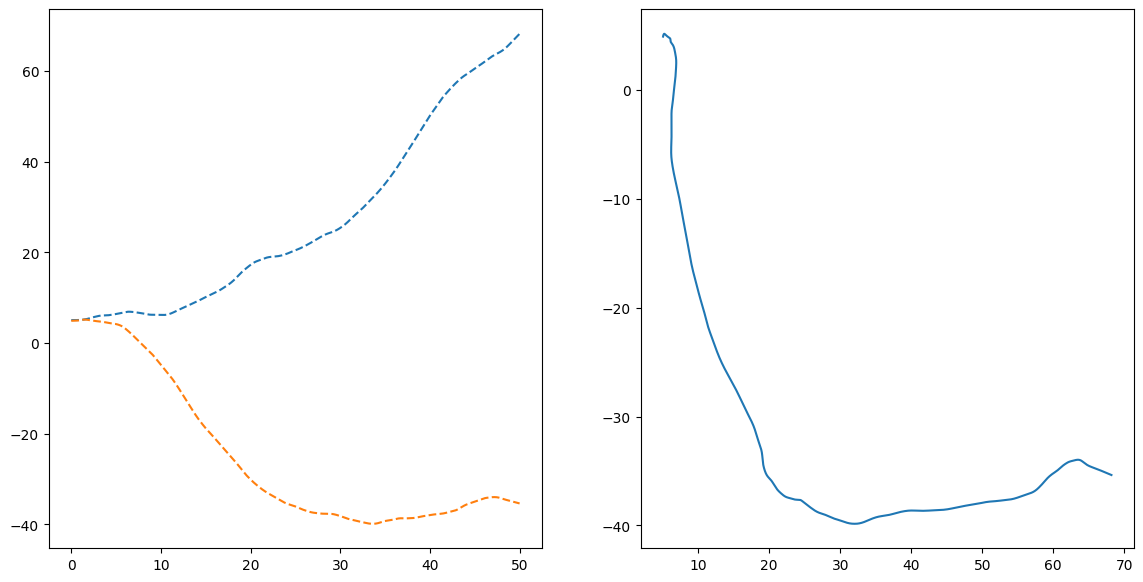

In [9]:
xs3 = np.array(x_list_jax_seq)[::-1]
us3 = np.array(u_list_jax_seq)
tt1 = np.arange(0, (blocks*steps)+1) * clqt.T  / steps/ blocks
f, (ax1, ax2) = plt.subplots(1,2, figsize=(14,7))
ax1.plot(tt1, xs3[:,0], '--', tt1, xs3[:,1], '--')


ax2.plot(xs3[:,0], xs3[:,1])
# ax2.plot( ms_s[:,0],ms_s[:,1])
# ax2.plot(positions[:,0], positions[:,1])

In [10]:
clqt, x0 = getCLQT(CLQT)


t0 = 0.0
dt = clqt.T / steps / blocks
Kx_list, d_list, S_list, v_list = parBackwardPass(clqt,blocks,steps,t0,dt)
phi0= np.linalg.solve(S_list[0] ,v_list[0])
phis1=np.linalg.solve(S_list ,v_list)

u_list,x_list = parForwardPass(clqt, phi0, Kx_list, d_list, blocks, steps,dt,t0,u_zoh=False)



k_rev: 4990
k_rev: 4980
k_rev: 4970
k_rev: 4960
k_rev: 4950
k_rev: 4940
k_rev: 4930
k_rev: 4920
k_rev: 4910
k_rev: 4900
k_rev: 4890
k_rev: 4880
k_rev: 4870
k_rev: 4860
k_rev: 4850
k_rev: 4840
k_rev: 4830
k_rev: 4820
k_rev: 4810
k_rev: 4800
k_rev: 4790
k_rev: 4780
k_rev: 4770
k_rev: 4760
k_rev: 4750
k_rev: 4740
k_rev: 4730
k_rev: 4720
k_rev: 4710
k_rev: 4700
k_rev: 4690
k_rev: 4680
k_rev: 4670
k_rev: 4660
k_rev: 4650
k_rev: 4640
k_rev: 4630
k_rev: 4620
k_rev: 4610
k_rev: 4600
k_rev: 4590
k_rev: 4580
k_rev: 4570
k_rev: 4560
k_rev: 4550
k_rev: 4540
k_rev: 4530
k_rev: 4520
k_rev: 4510
k_rev: 4500
k_rev: 4490
k_rev: 4480
k_rev: 4470
k_rev: 4460
k_rev: 4450
k_rev: 4440
k_rev: 4430
k_rev: 4420
k_rev: 4410
k_rev: 4400
k_rev: 4390
k_rev: 4380
k_rev: 4370
k_rev: 4360
k_rev: 4350
k_rev: 4340
k_rev: 4330
k_rev: 4320
k_rev: 4310
k_rev: 4300
k_rev: 4290
k_rev: 4280
k_rev: 4270
k_rev: 4260
k_rev: 4250
k_rev: 4240
k_rev: 4230
k_rev: 4220
k_rev: 4210
k_rev: 4200
k_rev: 4190
k_rev: 4180
k_rev: 4170
k_re

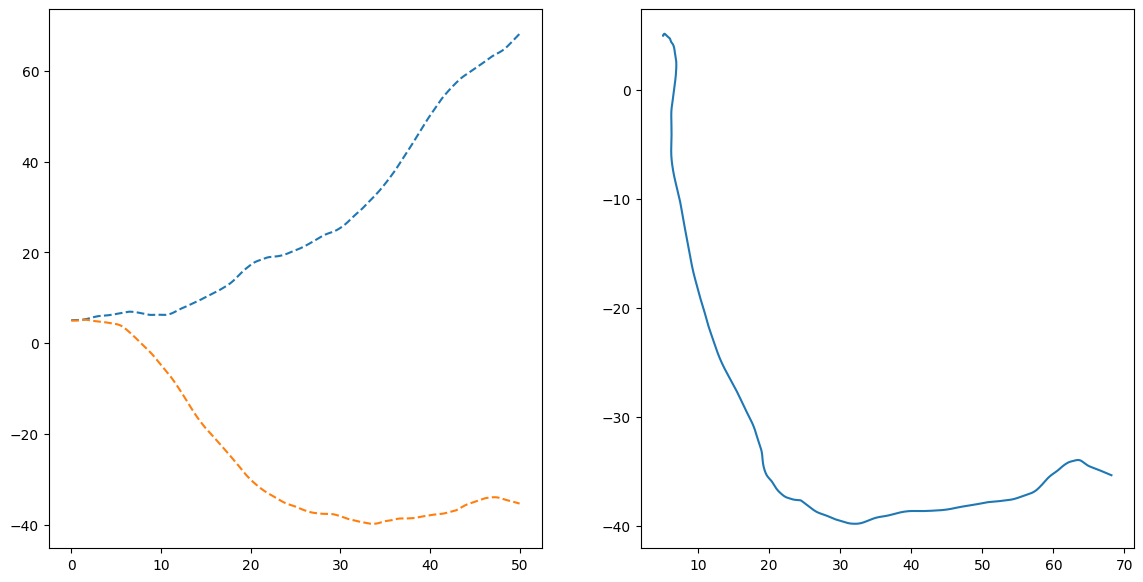

In [11]:
xs4 = np.array(x_list)[::-1]

us4 = np.array(u_list)
tt1 = np.arange(0, (blocks*steps)+1) * clqt.T  / steps/blocks


ff, (ax1, ax2) = plt.subplots(1,2, figsize=(14,7))
ax1.plot(tt1, xs4[:,0], '--', tt1, xs4[:,1], '--')
ax2.plot(xs4[:,0], xs4[:,1])


In [12]:
err = jnp.max(jnp.abs(xs4- xs3))
results=jnp.hstack((xs3,xs4))
print(err)

0.13259290932265563


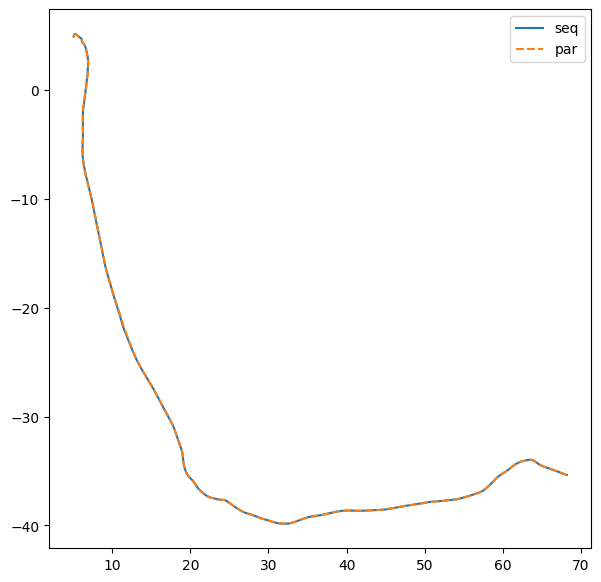

In [13]:
f, (ax1) = plt.subplots(1, figsize=(7,7))

ax1.plot(xs3[:,0], xs3[:,1])
ax1.plot( xs4[:,0],xs4[:,1],'--')
ax1.legend( ['seq', 'par'])


In [14]:
jax.numpy.allclose(xs3, xs4, rtol=1e-1)

Array(False, dtype=bool)

In [15]:
jax.numpy.allclose(xs3, ms_s, rtol=1e-1)

Array(False, dtype=bool)

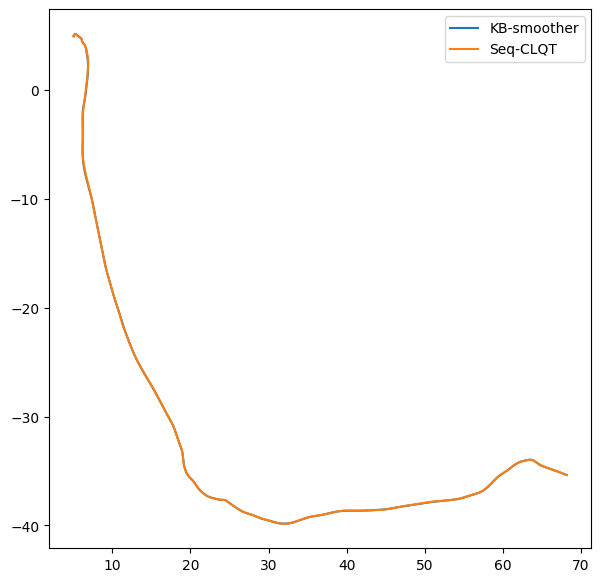

In [16]:
f, (ax1) = plt.subplots(1,1, figsize=(7,7))



ax1.plot(ms_s[:,0], ms_s[:,1])
ax1.plot(xs3[:,0], xs3[:,1])
ax1.legend( ['KB-smoother', 'Seq-CLQT'])


In [17]:
print(jnp.mean(jnp.abs(xs3-ms_s)))

0.020777032723342876
